<div style="background: linear-gradient(135deg, #1F497D 0%, #2E74B5 60%, #5B9BD5 100%);
     padding: 40px 50px; border-radius: 12px; margin-bottom: 10px;">
  <h1 style="color:white; font-size:2.2em; margin:0; font-weight:700; letter-spacing:1px;">
    Conductividad Hidráulica Efectiva
  </h1>
  <h2 style="color:#BDD7EE; font-size:1.3em; margin:8px 0 0 0; font-weight:400;">
    Media Geométrica en Medios Heterogéneos — Teoría, Fundamentos y Aplicación
  </h2>
  <hr style="border:1px solid rgba(255,255,255,0.3); margin:20px 0 15px 0;">
  <p style="color:#DEEAF1; margin:0; font-size:1.05em;">
    <b>Unidad 01</b> &nbsp;·&nbsp; Optimización en Aguas Subterráneas &nbsp;·&nbsp;
    Posgrado en Ciencias de la Tierra, UNAM
  </p>
</div>

In [1]:
import os, pathlib

# Asegura que las rutas de guardado existan relativas a la raíz del proyecto
ROOT = pathlib.Path(__file__).parent.parent if '__file__' in dir() else pathlib.Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
os.chdir(ROOT)

FIGS_DIR = ROOT / 'docs' / 'unidad_01' / 'notas'
FIGS_DIR.mkdir(parents=True, exist_ok=True)
print(f"Directorio de trabajo: {ROOT}")


Directorio de trabajo: /home/abelardo/UNAM/1.-Optimization_Course


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LogNorm
import matplotlib.patches as mpatches
import pandas as pd
import seaborn as sns
from scipy import stats
from scipy.stats import lognorm, gmean
import warnings
warnings.filterwarnings('ignore')

# Estilo global
plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'axes.prop_cycle': plt.cycler(color=['#1F497D','#E74C3C','#27AE60','#F39C12','#8E44AD']),
})

AZUL   = '#1F497D'
ROJO   = '#C0392B'
VERDE  = '#27AE60'
GRIS   = '#7F8C8D'
NARANJA= '#E67E22'

print("✓ Librerías cargadas correctamente")


✓ Librerías cargadas correctamente


## 1. Contexto y Motivación

### ¿Por qué necesitamos $K_{\text{eff}}$?

En modelación numérica de aguas subterráneas, las mediciones de conductividad
hidráulica $K$ se obtienen a escala de **punto** (ensayo de permeabilidad, prueba
de bombeo). Sin embargo, las celdas de un modelo numérico (MODFLOW, por ejemplo)
representan volúmenes de decenas a cientos de metros. Este desajuste de escala
exige un proceso de **escalamiento** (*upscaling*):

> *"Point measurements of hydraulic conductivity are made at a scale smaller than
> the nodal spacing of most groundwater flow models. Point measurements can be
> adjusted to fit the larger nodal spacing in a numerical model by **upscaling**."*
>
> — Anderson, Woessner & Hunt (2015, Box 5.3, p. 211)

### El problema de la heterogeneidad

Los acuíferos naturales son **heterogéneos**: $K$ varía varios órdenes de magnitud
en distancias cortas. Esta variabilidad sigue empíricamente una
**distribución lognormal** (Freeze, 1975; Gelhar, 1993):

$$Y = \ln(K) \sim \mathcal{N}(\mu_Y,\, \sigma_Y^2)$$

La elección del estimador de $K_{\text{eff}}$ impacta directamente la predicción
de flujo, velocidades de poro y tiempos de tránsito.


## 2. Marco Teórico — Las Tres Medias

Para un conjunto de valores $\{K_1, K_2, \ldots, K_n\}$, las medias clásicas son:

| Media | Fórmula | Caso físico |
|-------|---------|-------------|
| **Aritmética** | $K_A = \dfrac{1}{n}\sum_{i=1}^n K_i$ | Flujo **horizontal** en capas paralelas |
| **Geométrica** | $K_G = \left(\prod_{i=1}^n K_i\right)^{1/n} = \exp\!\left(\dfrac{1}{n}\sum \ln K_i\right)$ | Medio **isótropo aleatorio** |
| **Armónica** | $K_H = \dfrac{n}{\sum_{i=1}^n 1/K_i}$ | Flujo **vertical** en capas en serie |

Siempre se cumple: $K_H \leq K_G \leq K_A$

### 2.1 La Media Geométrica como Estimador de $K_{\text{eff}}$

**Cardwell & Parsons (1945)** demostraron que para un medio heterogéneo con
$K$ distribuida lognormalmente, la conductividad efectiva está acotada:

$$K_H \leq K_{\text{eff}} \leq K_A$$

Para un medio **isótropo en 2D** y distribución lognormal (Matheron, 1967; Gelhar & Axness, 1983):

$$\boxed{K_{\text{eff}}^{2D} = K_G = e^{\mu_Y}}$$

Para **3D** (Dagan, 1993; Renard & de Marsily, 1997):

$$K_{\text{eff}}^{3D} = K_G \cdot e^{\,\sigma_Y^2/6}$$

Donde $\mu_Y$ y $\sigma_Y^2$ son la media y varianza de $Y = \ln(K)$.

### 2.2 Upscaling en Capas (Anderson et al., 2015)

Para una secuencia de $m$ láminas horizontales (Box 5.3):

$$K_h = \frac{\sum_{k=1}^m K_k \, b_k}{B} \quad \text{(media aritmética ponderada)}$$

$$K_v = \frac{B}{\sum_{k=1}^m b_k / K_k} \quad \text{(media armónica ponderada)}$$

El **cociente de anisotropía** $K_h/K_v$ resulta de la heterogeneidad estratigráfica.


## 3. Fuentes de Literatura

<div style="background:#F0F4FA; border-left:4px solid #1F497D;
            padding:18px 22px; border-radius:6px; margin:10px 0;">

**Referencias fundamentales:**

- **Cardwell, W. T. & Parsons, R. L. (1945).** Average permeabilities of heterogeneous
  oil sands. *Trans. AIME*, 160, 34–42.
  → *Trabajo seminal que establece los límites aritmético/armónico y propone la media geométrica.*

- **Freeze, R. A. (1975).** A stochastic-conceptual analysis of one-dimensional groundwater
  flow in nonuniform homogeneous media. *Water Resources Research*, 11(5), 725–741.
  → *Formaliza la distribución lognormal de K en medios naturales.*

- **Matheron, G. (1967).** *Éléments pour une théorie des milieux poreux.* Masson, Paris.
  → *Prueba analítica de K_eff = K_G para medios aleatorios isótropos en 2D.*

- **Gelhar, L. W. & Axness, C. L. (1983).** Three-dimensional stochastic analysis of
  macrodispersion in aquifers. *Water Resources Research*, 19(1), 161–180.
  → *Extiende el resultado a 3D: K_eff = K_G · exp(σ²/6).*

- **Dagan, G. (1993).** Higher-order correction of effective permeability of heterogeneous
  isotropic formations of lognormal conductivity distribution. *Transport in Porous Media*, 12, 279–290.

- **Renard, Ph. & de Marsily, G. (1997).** Calculating effective permeability: a review.
  *Advances in Water Resources*, 20(5–6), 253–278.
  → *Revisión exhaustiva de métodos de upscaling. Citado en Anderson et al. (2015).*

- **Anderson, M. P., Woessner, W. W. & Hunt, R. J. (2015).** *Applied Groundwater Modeling
  (2nd ed.).* Academic Press. Box 5.3, pp. 211–214.
  → *Aplicación práctica en modelación numérica; ecuaciones de K_h y K_v por capas.*

- **Peralta, R. C. & Kalwij, I. M. (2012).** *Groundwater Optimization Handbook.*
  CRC Press / IWA Publishing. Tabla 1.1, pp. 17–18.
  → *Rangos de K por material geológico; contexto de incertidumbre paramétrica.*

</div>


## 4. Implementación en Python

In [3]:
# ─── Funciones de upscaling ───────────────────────────────────────────────

def media_aritmetica(K, pesos=None):
    """K_A: flujo horizontal en capas paralelas."""
    if pesos is None:
        return np.mean(K)
    pesos = np.asarray(pesos)
    return np.sum(K * pesos) / np.sum(pesos)


def media_geometrica(K):
    """K_G: medio isótropo aleatorio con K lognormal (Matheron, 1967)."""
    return np.exp(np.mean(np.log(K)))


def media_armonica(K, pesos=None):
    """K_H: flujo vertical en capas en serie."""
    if pesos is None:
        return len(K) / np.sum(1.0 / K)
    pesos = np.asarray(pesos)
    return np.sum(pesos) / np.sum(pesos / K)


def keff_3d_lognormal(K):
    """
    K_eff para medio isótropo 3D con distribución lognormal
    (Gelhar & Axness, 1983; Dagan, 1993):
        K_eff = K_G · exp(σ²_Y / 6)
    """
    Y = np.log(K)
    mu_Y  = np.mean(Y)
    sig2_Y = np.var(Y)
    return np.exp(mu_Y + sig2_Y / 6.0)


def upscaling_capas(K_capas, espesores):
    """
    Upscaling por capas horizontales (Anderson et al., 2015, Box 5.3).
    Retorna K_h (aritmética ponderada) y K_v (armónica ponderada).
    """
    K_capas  = np.asarray(K_capas,  dtype=float)
    espesores = np.asarray(espesores, dtype=float)
    B  = np.sum(espesores)
    Kh = np.sum(K_capas * espesores) / B
    Kv = B / np.sum(espesores / K_capas)
    return Kh, Kv


# ─── Verificación rápida ──────────────────────────────────────────────────
K_test = np.array([1e-4, 1e-3, 1e-2, 1e-1, 1e0])   # m/s

print("─" * 42)
print(f"  K_A  (aritmética): {media_aritmetica(K_test):.4e} m/s")
print(f"  K_G  (geométrica): {media_geometrica(K_test):.4e} m/s")
print(f"  K_H  (armónica)  : {media_armonica(K_test):.4e} m/s")
print(f"  K_eff 3D lognorm : {keff_3d_lognormal(K_test):.4e} m/s")
print("─" * 42)
print(f"  Relación K_A/K_H : {media_aritmetica(K_test)/media_armonica(K_test):.1f}x")
print(f"  Cumple K_H ≤ K_G ≤ K_A: "
      f"{media_armonica(K_test) <= media_geometrica(K_test) <= media_aritmetica(K_test)}")


──────────────────────────────────────────
  K_A  (aritmética): 2.2222e-01 m/s
  K_G  (geométrica): 1.0000e-02 m/s
  K_H  (armónica)  : 4.5000e-04 m/s
  K_eff 3D lognorm : 5.8550e-02 m/s
──────────────────────────────────────────
  Relación K_A/K_H : 493.8x
  Cumple K_H ≤ K_G ≤ K_A: True


## 5. Comparación Visual de las Tres Medias

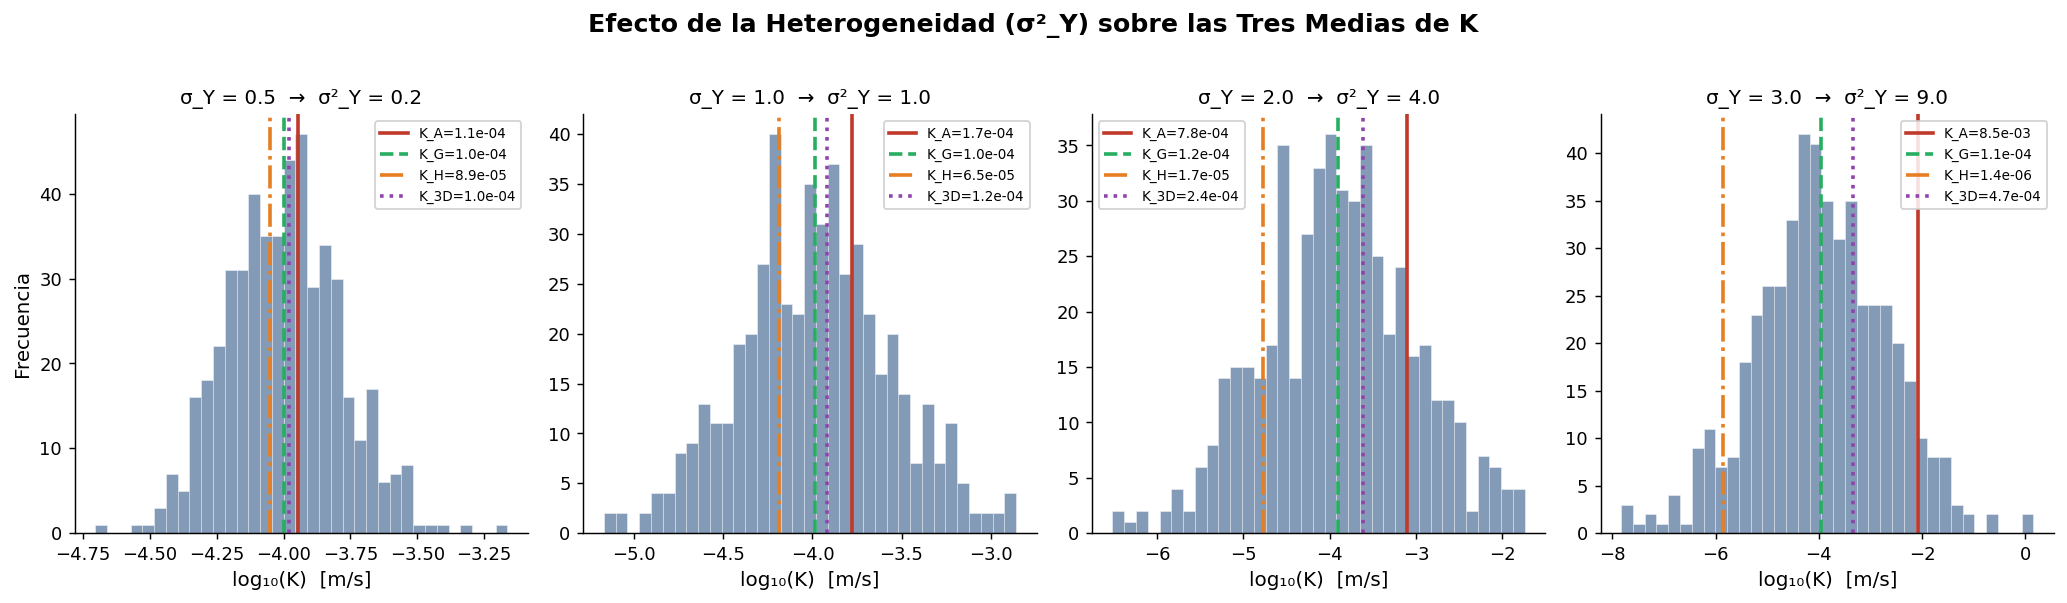

→ Con mayor heterogeneidad (σ²_Y ↑), la divergencia entre medias se amplifica.


In [4]:
np.random.seed(42)

# Generar muestras lognormales con distintas varianzas
sigma_Y_vals = [0.5, 1.0, 2.0, 3.0]
mu_Y = np.log(1e-4)          # K_G de referencia = 1e-4 m/s

fig, axes = plt.subplots(1, 4, figsize=(16, 4.5), sharey=False)
fig.suptitle("Efecto de la Heterogeneidad (σ²_Y) sobre las Tres Medias de K",
             fontsize=14, fontweight='bold', y=1.02)

for ax, sig in zip(axes, sigma_Y_vals):
    # Muestra lognormal
    K = np.random.lognormal(mean=mu_Y, sigma=sig, size=500)

    Ka = media_aritmetica(K)
    Kg = media_geometrica(K)
    Kh = media_armonica(K)
    Ke = keff_3d_lognormal(K)

    # Histograma en escala log
    ax.hist(np.log10(K), bins=35, color=AZUL, alpha=0.55, edgecolor='white', lw=0.4)
    ymax = ax.get_ylim()[1]

    # Líneas de cada media
    for val, label, color, ls in [
        (Ka, f'K_A={Ka:.1e}', ROJO,    '-'),
        (Kg, f'K_G={Kg:.1e}', VERDE,   '--'),
        (Kh, f'K_H={Kh:.1e}', NARANJA, '-.'),
        (Ke, f'K_3D={Ke:.1e}', '#8E44AD', ':'),
    ]:
        ax.axvline(np.log10(val), color=color, lw=2, ls=ls, label=label)

    ax.set_title(f'σ_Y = {sig}  →  σ²_Y = {sig**2:.1f}', fontsize=11)
    ax.set_xlabel('log₁₀(K)  [m/s]')
    ax.set_ylabel('Frecuencia' if ax == axes[0] else '')
    ax.legend(fontsize=7.5, framealpha=0.85)

plt.tight_layout()
plt.savefig('docs/unidad_01/notas/comparacion_medias.png', dpi=150, bbox_inches='tight')
plt.show()
print("→ Con mayor heterogeneidad (σ²_Y ↑), la divergencia entre medias se amplifica.")


np.random.seed(42)

sigma_Y_vals = [0.5, 1.0, 2.0, 3.0]
mu_Y = np.log(1e-4)

fig, axes = plt.subplots(1, 4, figsize=(16, 4.5), sharey=False)
fig.suptitle("Efecto de la Heterogeneidad (sigma_Y) sobre las Tres Medias de K",
             fontsize=14, fontweight='bold', y=1.02)

for ax, sig in zip(axes, sigma_Y_vals):
    K = np.random.lognormal(mean=mu_Y, sigma=sig, size=500)

    Ka = media_aritmetica(K)
    Kg = media_geometrica(K)
    Kh = media_armonica(K)
    Ke = keff_3d_lognormal(K)

    ax.hist(np.log10(K), bins=35, color=AZUL, alpha=0.55, edgecolor='white', lw=0.4)

    estimadores = [
        (Ka, f'K_A={Ka:.1e}', ROJO,     '-'),
        (Kg, f'K_G={Kg:.1e}', VERDE,    '--'),
        (Kh, f'K_H={Kh:.1e}', NARANJA,  '-.'),
        (Ke, f'K_3D={Ke:.1e}','#8E44AD', ':'),
    ]
    for val, label, color, ls in estimadores:
        ax.axvline(np.log10(val), color=color, lw=2, ls=ls, label=label)

    ax.set_title(f'sigma_Y = {sig}  ->  sigma2_Y = {sig**2:.1f}', fontsize=11)
    ax.set_xlabel('log10(K)  [m/s]')
    ax.set_ylabel('Frecuencia' if ax == axes[0] else '')
    ax.legend(fontsize=7.5, framealpha=0.85)

plt.tight_layout()
plt.savefig('docs/unidad_01/notas/comparacion_medias.png', dpi=150, bbox_inches='tight')
plt.show()
print("-> Con mayor heterogeneidad (sigma2_Y alto), la divergencia entre medias se amplifica.")

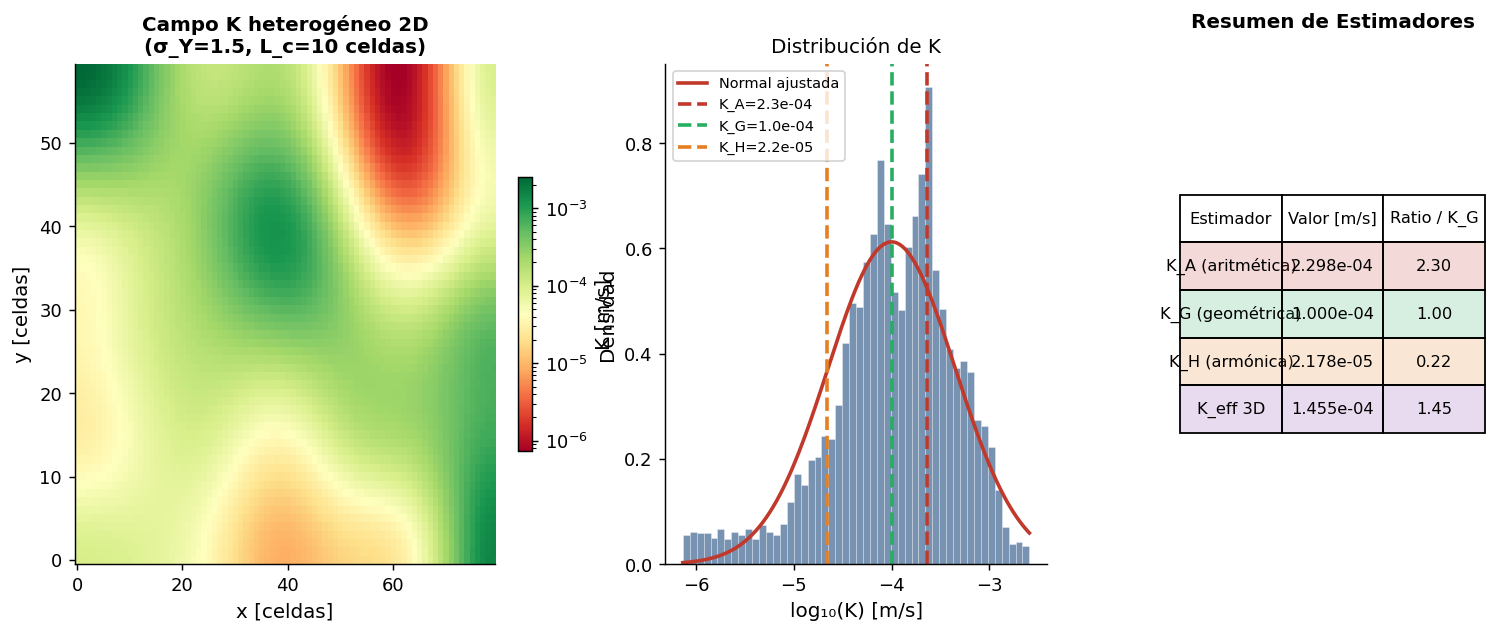

In [5]:
from scipy.ndimage import gaussian_filter

np.random.seed(7)

# Parámetros del campo
nx, ny   = 80, 60
mu_Y     = np.log(1e-4)    # m/s
sigma_Y  = 1.5             # varianza moderada-alta
corr_len = 10              # longitud de correlación (celdas)

# Campo lognormal con correlación espacial (filtrado gaussiano)
Y_rand  = np.random.normal(0, sigma_Y, (ny, nx))
Y_corr  = gaussian_filter(Y_rand, sigma=corr_len)
# Renormalizar para preservar μ y σ
Y_corr  = (Y_corr - Y_corr.mean()) / Y_corr.std() * sigma_Y + mu_Y
K_field = np.exp(Y_corr)

# Calcular medias del campo completo
Ka = media_aritmetica(K_field.ravel())
Kg = media_geometrica(K_field.ravel())
Kh = media_armonica(K_field.ravel())
Ke = keff_3d_lognormal(K_field.ravel())

fig = plt.figure(figsize=(14, 5))
gs  = gridspec.GridSpec(1, 3, width_ratios=[3, 2.5, 2], wspace=0.35)

# --- Mapa 2D del campo K ---
ax0 = fig.add_subplot(gs[0])
im  = ax0.imshow(K_field, cmap='RdYlGn', norm=LogNorm(vmin=K_field.min(), vmax=K_field.max()),
                 aspect='auto', origin='lower')
plt.colorbar(im, ax=ax0, label='K [m/s]', fraction=0.03)
ax0.set_title(f'Campo K heterogéneo 2D\n(σ_Y={sigma_Y}, L_c={corr_len} celdas)', fontsize=11, fontweight='bold')
ax0.set_xlabel('x [celdas]'); ax0.set_ylabel('y [celdas]')

# --- Distribución log(K) ---
ax1 = fig.add_subplot(gs[1])
log_K = np.log10(K_field.ravel())
ax1.hist(log_K, bins=50, color=AZUL, alpha=0.6, edgecolor='white', lw=0.3, density=True)
# Ajuste normal teórico
x_range = np.linspace(log_K.min(), log_K.max(), 200)
mu_fit, std_fit = stats.norm.fit(log_K)
ax1.plot(x_range, stats.norm.pdf(x_range, mu_fit, std_fit), color=ROJO, lw=2, label='Normal ajustada')
for kval, klbl, kcol in [(Ka,'K_A',ROJO),(Kg,'K_G',VERDE),(Kh,'K_H',NARANJA)]:
    ax1.axvline(np.log10(kval), color=kcol, lw=2, ls='--', label=f'{klbl}={kval:.1e}')
ax1.set_xlabel('log₁₀(K) [m/s]'); ax1.set_ylabel('Densidad')
ax1.set_title('Distribución de K', fontsize=11)
ax1.legend(fontsize=8)

# --- Tabla de medias ---
ax2 = fig.add_subplot(gs[2])
ax2.axis('off')
tabla = pd.DataFrame({
    'Estimador': ['K_A (aritmética)', 'K_G (geométrica)', 'K_H (armónica)', 'K_eff 3D'],
    'Valor [m/s]': [f'{Ka:.3e}', f'{Kg:.3e}', f'{Kh:.3e}', f'{Ke:.3e}'],
    'Ratio / K_G': [f'{Ka/Kg:.2f}', '1.00', f'{Kh/Kg:.2f}', f'{Ke/Kg:.2f}'],
})
t = ax2.table(cellText=tabla.values, colLabels=tabla.columns,
              loc='center', cellLoc='center')
t.auto_set_font_size(False); t.set_fontsize(9); t.scale(1, 2.2)
# Colorear filas
colores_fila = [ROJO, VERDE, NARANJA, '#8E44AD']
for i, color in enumerate(colores_fila):
    for j in range(3):
        t[i+1, j].set_facecolor(color + '30')
ax2.set_title('Resumen de Estimadores', fontsize=11, fontweight='bold', pad=20)

plt.savefig('docs/unidad_01/notas/campo_K_2D.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Análisis de Sensibilidad — Efecto de σ²_Y

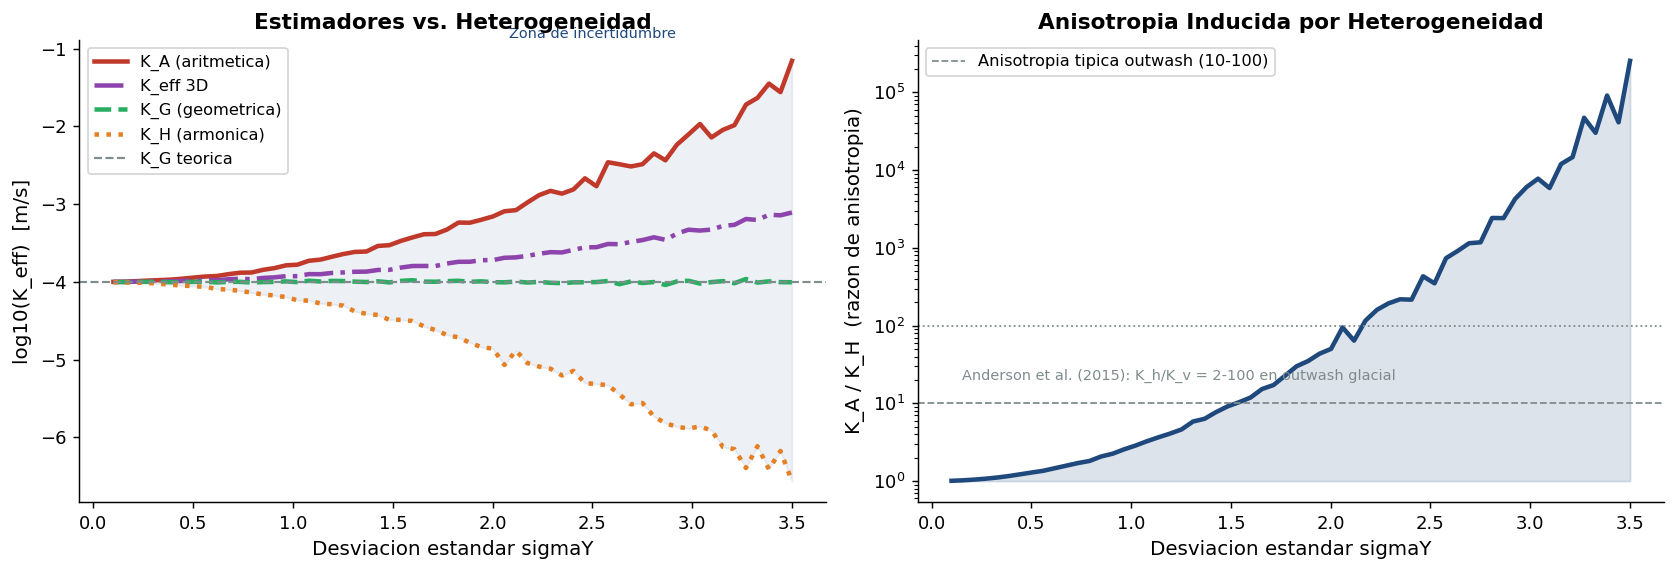

In [6]:
sig_range = np.linspace(0.1, 3.5, 60)
mu_Y_ref  = np.log(1e-4)

Ka_vals, Kg_vals, Kh_vals, Ke3_vals = [], [], [], []

np.random.seed(0)
for sig in sig_range:
    K = np.random.lognormal(mu_Y_ref, sig, 5000)
    Ka_vals.append(media_aritmetica(K))
    Kg_vals.append(media_geometrica(K))
    Kh_vals.append(media_armonica(K))
    Ke3_vals.append(keff_3d_lognormal(K))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.plot(sig_range, np.log10(Ka_vals),  color=ROJO,     lw=2.5, label='K_A (aritmetica)')
ax.plot(sig_range, np.log10(Ke3_vals), color='#8E44AD', lw=2.5, label='K_eff 3D', ls='-.')
ax.plot(sig_range, np.log10(Kg_vals),  color=VERDE,    lw=2.5, label='K_G (geometrica)', ls='--')
ax.plot(sig_range, np.log10(Kh_vals),  color=NARANJA,  lw=2.5, label='K_H (armonica)', ls=':')
ax.axhline(np.log10(np.exp(mu_Y_ref)), color=GRIS, lw=1.2, ls='--', label='K_G teorica')
ax.fill_between(sig_range, np.log10(Kh_vals), np.log10(Ka_vals), alpha=0.08, color=AZUL)
ax.set_xlabel('Desviacion estandar sigmaY', fontsize=11)
ax.set_ylabel('log10(K_eff)  [m/s]', fontsize=11)
ax.set_title('Estimadores vs. Heterogeneidad', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.text(2.5, np.log10(Ka_vals[-1])+0.3, 'Zona de incertidumbre', color=AZUL, fontsize=8, ha='center')

ax2 = axes[1]
ratio = np.array(Ka_vals) / np.array(Kh_vals)
ax2.semilogy(sig_range, ratio, color=AZUL, lw=2.5)
ax2.fill_between(sig_range, 1, ratio, alpha=0.15, color=AZUL)
ax2.axhline(10,  color=GRIS, ls='--', lw=1, label='Anisotropia tipica outwash (10-100)')
ax2.axhline(100, color=GRIS, ls=':', lw=1)
ax2.set_xlabel('Desviacion estandar sigmaY', fontsize=11)
ax2.set_ylabel('K_A / K_H  (razon de anisotropia)', fontsize=11)
ax2.set_title('Anisotropia Inducida por Heterogeneidad', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.text(0.15, 20, 'Anderson et al. (2015): K_h/K_v = 2-100 en outwash glacial', fontsize=8, color=GRIS)

plt.tight_layout()
plt.savefig('docs/unidad_01/notas/sensibilidad_sigma.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Ejemplo de Aplicación — Acuífero Aluvial Estratificado

### Contexto

Se tiene un acuífero aluvial con **5 unidades geológicas** caracterizadas por ensayos
de permeabilidad de laboratorio. Se requiere calcular la conductividad hidráulica
efectiva para parametrizar una celda del modelo MODFLOW.

**Datos de campo** (Peralta, 2012; Tabla 1.1 — materiales típicos):


In [7]:
# ─── Datos del acuífero estratificado ────────────────────────────────────
capas = pd.DataFrame({
    'Unidad':     ['Grava media',  'Arena gruesa', 'Arena media',
                   'Arena fina',  'Limo arenoso'],
    'Espesor_m':  [3.5,            8.0,            12.0,            6.5,  4.0],
    'K_ms':       [5.5e-3,         8.2e-4,         1.4e-4,          2.1e-5, 3.0e-6],
})

capas['b_k']   = capas['Espesor_m']
capas['K*b']   = capas['K_ms'] * capas['Espesor_m']
capas['b/K']   = capas['Espesor_m'] / capas['K_ms']
capas['ln(K)'] = np.log(capas['K_ms'])

B = capas['Espesor_m'].sum()

Kh, Kv = upscaling_capas(capas['K_ms'].values, capas['Espesor_m'].values)
Kg = media_geometrica(capas['K_ms'].values)
Ka = media_aritmetica(capas['K_ms'].values, capas['Espesor_m'].values)
Ke3= keff_3d_lognormal(capas['K_ms'].values)

print("=" * 52)
print(f"  Espesor total del acuífero:  B = {B:.1f} m")
print("=" * 52)
print(f"  K_h (aritmética ponderada):  {Kh:.3e} m/s")
print(f"  K_v (armónica ponderada) :   {Kv:.3e} m/s")
print(f"  K_G (geométrica)         :   {Kg:.3e} m/s")
print(f"  K_eff 3D (Dagan, 1993)   :   {Ke3:.3e} m/s")
print(f"  Anisotropía K_h/K_v      :   {Kh/Kv:.1f}")
print("=" * 52)
print("  -> Valor recomendado para MODFLOW:")
print(f"     Kh = {Kh:.3e} m/s  |  Kv = {Kv:.3e} m/s")

display(capas[['Unidad','Espesor_m','K_ms','K*b','b/K']].style
        .format({'Espesor_m':'{:.1f}','K_ms':'{:.2e}','K*b':'{:.4f}','b/K':'{:.0f}'})
        .background_gradient(subset=['K_ms'], cmap='RdYlGn')
        .set_caption('Tabla 1 — Datos del acuífero estratificado')
        .set_table_styles([{'selector':'caption','props':[('font-weight','bold'),
                                                          ('font-size','11px')]}]))


  Espesor total del acuífero:  B = 34.0 m
  K_h (aritmética ponderada):  8.129e-04 m/s
  K_v (armónica ponderada) :   1.955e-05 m/s
  K_G (geométrica)         :   1.318e-04 m/s
  K_eff 3D (Dagan, 1993)   :   4.225e-04 m/s
  Anisotropía K_h/K_v      :   41.6
  -> Valor recomendado para MODFLOW:
     Kh = 8.129e-04 m/s  |  Kv = 1.955e-05 m/s


,Unidad,Espesor_m,K_ms,K*b,b/K
0,Grava media,3.5,5.50e-03,0.0192,636
1,Arena gruesa,8.0,8.20e-04,0.0066,9756
2,Arena media,12.0,1.40e-04,0.0017,85714
3,Arena fina,6.5,2.10e-05,0.0001,309524
4,Limo arenoso,4.0,3.00e-06,0.0000,1333333


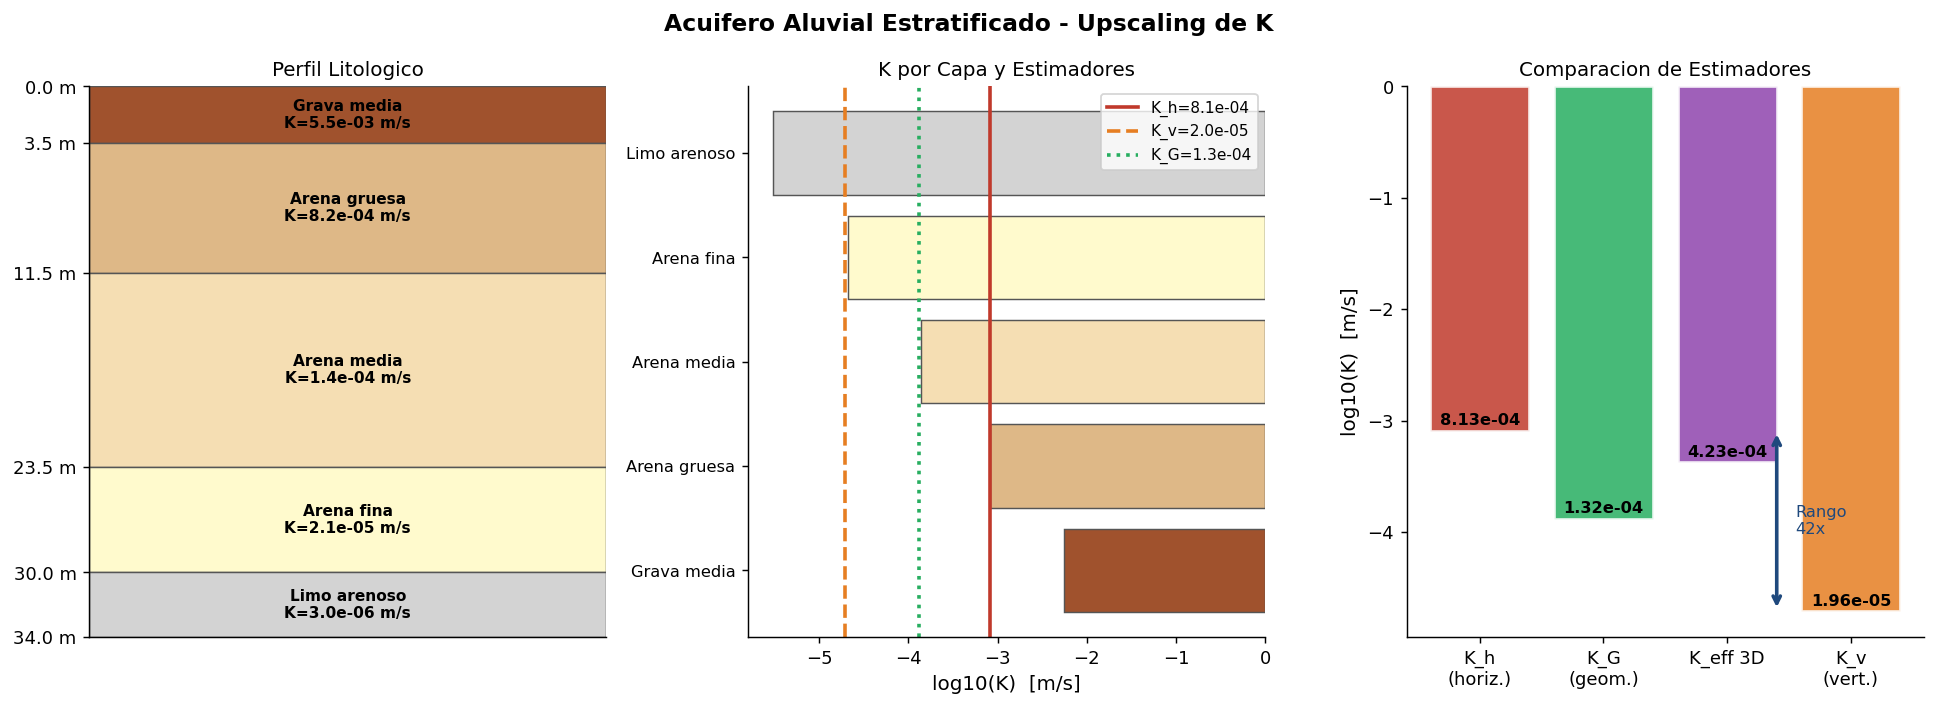

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
fig.suptitle('Acuifero Aluvial Estratificado - Upscaling de K', fontsize=13, fontweight='bold')

colores_geo = ['#A0522D','#DEB887','#F5DEB3','#FFFACD','#D3D3D3']

# Panel 1: Perfil litologico
ax = axes[0]
y_bottom = 0
for idx, row in capas.iterrows():
    ax.barh(y_bottom + row['Espesor_m']/2, width=1,
            height=row['Espesor_m'], left=0,
            color=colores_geo[idx], edgecolor='#555', lw=0.8)
    label_txt = f"{row['Unidad']}\nK={row['K_ms']:.1e} m/s"
    ax.text(0.5, y_bottom + row['Espesor_m']/2, label_txt,
            ha='center', va='center', fontsize=8.5, fontweight='bold')
    y_bottom += row['Espesor_m']

ax.set_xlim(0, 1); ax.set_ylim(0, B)
ax.set_yticks(np.cumsum([0]+capas['Espesor_m'].tolist()))
ax.set_yticklabels([f'{d:.1f} m' for d in np.cumsum([0]+capas['Espesor_m'].tolist())])
ax.invert_yaxis()
ax.set_title('Perfil Litologico', fontsize=11)
ax.set_xticks([])

# Panel 2: K por capa y medias
ax2 = axes[1]
y_pos = np.arange(len(capas))
ax2.barh(y_pos, np.log10(capas['K_ms']), color=colores_geo, edgecolor='#555', lw=0.8)
for val, col, lbl, ls in [(Kh, ROJO, f'K_h={Kh:.1e}', '-'),
                           (Kv, NARANJA, f'K_v={Kv:.1e}', '--'),
                           (Kg, VERDE, f'K_G={Kg:.1e}', ':')]:
    ax2.axvline(np.log10(val), color=col, lw=2, ls=ls, label=lbl)
ax2.set_yticks(y_pos)
ax2.set_yticklabels(capas['Unidad'], fontsize=9)
ax2.set_xlabel('log10(K)  [m/s]')
ax2.set_title('K por Capa y Estimadores', fontsize=11)
ax2.legend(fontsize=8.5)

# Panel 3: Comparacion de estimadores
ax3 = axes[2]
labels_bar = ['K_h\n(horiz.)', 'K_G\n(geom.)', 'K_eff 3D', 'K_v\n(vert.)']
values_bar = [Kh, Kg, Ke3, Kv]
cols_bar   = [ROJO, VERDE, '#8E44AD', NARANJA]
bars3 = ax3.bar(labels_bar, np.log10(values_bar), color=cols_bar, alpha=0.85, edgecolor='white', lw=1.5)
for bar, val in zip(bars3, values_bar):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{val:.2e}', ha='center', fontsize=9, fontweight='bold')
ax3.set_ylabel('log10(K)  [m/s]')
ax3.set_title('Comparacion de Estimadores', fontsize=11)
ax3.annotate('', xy=(2.4, np.log10(Kv)), xytext=(2.4, np.log10(Kh)),
             arrowprops=dict(arrowstyle='<->', color=AZUL, lw=2))
ax3.text(2.55, (np.log10(Kh)+np.log10(Kv))/2,
         f'Rango\n{Kh/Kv:.0f}x', color=AZUL, fontsize=9, va='center')

plt.tight_layout()
plt.savefig('docs/unidad_01/notas/aplicacion_acuifero.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Propagación de Incertidumbre — Simulación Monte Carlo

La incertidumbre en las mediciones de $K$ se propaga al estimador $K_{\text{eff}}$.
Cuantificamos esta incertidumbre mediante 10,000 realizaciones Monte Carlo.


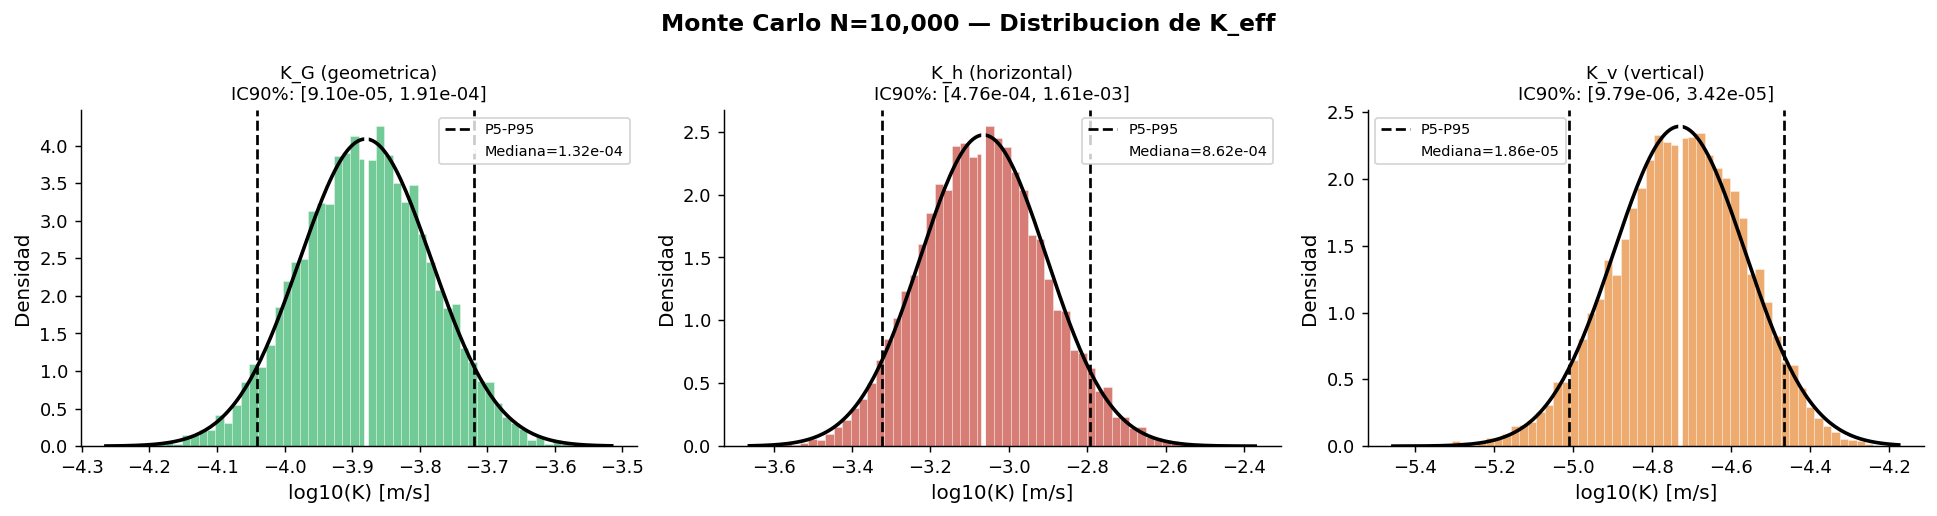

-------------------------------------------------------
  K_G  Media: 1.351e-04  CV: 22.7%
  K_h  Media: 9.243e-04  CV: 39.7%
  K_v  Media: 2.001e-05  CV: 38.1%
-------------------------------------------------------


In [9]:
np.random.seed(42)
N_mc = 10_000

mu_Y_mc  = np.log(capas['K_ms'].values)
sig_Y_mc = 0.5 * np.ones(len(capas))

Kg_mc, Kh_mc, Kv_mc = [], [], []
for _ in range(N_mc):
    K_real = np.exp(np.random.normal(mu_Y_mc, sig_Y_mc))
    Kg_mc.append(media_geometrica(K_real))
    kh_, kv_ = upscaling_capas(K_real, capas['Espesor_m'].values)
    Kh_mc.append(kh_); Kv_mc.append(kv_)

Kg_mc = np.array(Kg_mc)
Kh_mc = np.array(Kh_mc)
Kv_mc = np.array(Kv_mc)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f'Monte Carlo N={N_mc:,} — Distribucion de K_eff', fontsize=13, fontweight='bold')

for ax, arr, lbl, col in zip(axes,
                              [Kg_mc, Kh_mc, Kv_mc],
                              ['K_G (geometrica)', 'K_h (horizontal)', 'K_v (vertical)'],
                              [VERDE, ROJO, NARANJA]):
    log_arr = np.log10(arr)
    ax.hist(log_arr, bins=60, color=col, alpha=0.65, edgecolor='white', lw=0.3, density=True)
    mu_fit, s = log_arr.mean(), log_arr.std()
    x = np.linspace(log_arr.min(), log_arr.max(), 200)
    ax.plot(x, stats.norm.pdf(x, mu_fit, s), color='black', lw=2)
    p5  = np.percentile(log_arr, 5)
    p95 = np.percentile(log_arr, 95)
    ax.axvline(p5,  color='black', lw=1.5, ls='--', label='P5-P95')
    ax.axvline(p95, color='black', lw=1.5, ls='--')
    mediana_val = 10**mu_fit
    ax.axvline(mu_fit, color='white', lw=2.5, ls='-', label=f'Mediana={mediana_val:.2e}')
    ci_lo = 10**p5
    ci_hi = 10**p95
    titulo = f'{lbl}\nIC90%: [{ci_lo:.2e}, {ci_hi:.2e}]'
    ax.set_xlabel('log10(K) [m/s]')
    ax.set_ylabel('Densidad')
    ax.set_title(titulo, fontsize=10)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('docs/unidad_01/notas/monte_carlo_Keff.png', dpi=150, bbox_inches='tight')
plt.show()

print('-' * 55)
print(f"  K_G  Media: {Kg_mc.mean():.3e}  CV: {Kg_mc.std()/Kg_mc.mean()*100:.1f}%")
print(f"  K_h  Media: {Kh_mc.mean():.3e}  CV: {Kh_mc.std()/Kh_mc.mean()*100:.1f}%")
print(f"  K_v  Media: {Kv_mc.mean():.3e}  CV: {Kv_mc.std()/Kv_mc.mean()*100:.1f}%")
print('-' * 55)

## 10. Conclusiones y Recomendaciones para Modelación

<div style="background:#F8FFF8; border-left:4px solid #27AE60; padding:16px 20px; border-radius:6px;">

**Síntesis:**

1. **La media geométrica** $K_G$ es el estimador más robusto para medios
   heterogéneos isótropos con distribución lognormal de $K$ (Matheron, 1967;
   Gelhar & Axness, 1983). Para una celda 3D: $K_{\text{eff}} = K_G \cdot e^{\sigma_Y^2/6}$.

2. **Upscaling por capas** (Anderson et al., 2015): para secuencias estratificadas,
   $K_h$ (flujo horizontal) = media aritmética ponderada; $K_v$ (flujo vertical) =
   media armónica ponderada. La anisotropía resultante $K_h/K_v$ refleja la heterogeneidad litológica.

3. **La heterogeneidad amplifica la incertidumbre**: a mayor $\sigma_Y^2$, mayor
   divergencia entre $K_A$, $K_G$ y $K_H$, y mayor variabilidad en $K_{\text{eff}}$.

4. **Recomendación práctica**: en la calibración de MODFLOW, utilizar
   $K_h$ como valor inicial del parámetro horizontal y $K_h/K_v$ entre 10–100
   para acuíferos aluviales no consolidados (Todd & Mays, 2005; Anderson et al., 2015).

</div>

---

## Referencias

- Anderson, M. P., Woessner, W. W. & Hunt, R. J. (2015). *Applied Groundwater Modeling* (2ª ed.). Academic Press. Box 5.3, pp. 211–214.
- Cardwell, W. T. & Parsons, R. L. (1945). Average permeabilities of heterogeneous oil sands. *Trans. AIME*, 160, 34–42.
- Dagan, G. (1993). Higher-order correction of effective permeability. *Transport in Porous Media*, 12, 279–290.
- Freeze, R. A. (1975). A stochastic-conceptual analysis of one-dimensional groundwater flow. *Water Resources Research*, 11(5), 725–741.
- Gelhar, L. W. & Axness, C. L. (1983). Three-dimensional stochastic analysis of macrodispersion. *Water Resources Research*, 19(1), 161–180.
- Matheron, G. (1967). *Éléments pour une théorie des milieux poreux.* Masson, Paris.
- Peralta, R. C. & Kalwij, I. M. (2012). *Groundwater Optimization Handbook.* CRC Press. Tabla 1.1.
- Renard, Ph. & de Marsily, G. (1997). Calculating effective permeability: a review. *Advances in Water Resources*, 20(5–6), 253–278.
